# Machine Learning 1 - Nearest Neighbors and Decision Trees

## Lab objectives

* Classification with decision trees and random forests.
* Cross-validation and evaluation.

In [1]:
from lab_tools import CIFAR10, get_hog_image

dataset = CIFAR10('CIFAR10/')

Pre-loading training data
Pre-loading test data


# 1. Nearest Neighbor

The following example uses the Nearest Neighbor algorithm on the Histogram of Gradient decriptors in the dataset.

In [4]:
from sklearn.neighbors import KNeighborsClassifier

clf = KNeighborsClassifier(n_neighbors=1)
clf.fit( dataset.train['hog'], dataset.train['labels'] )

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


* What is the **descriptive performance** of this classifier ?
* Modify the code to estimate the **predictive performance**.
* Use cross-validation to find the best hyper-parameters for this method.

In [ ]:
# -- Your code here -- #

# Descriptive performance
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

pred_descr = clf.predict(dataset.train['hog'])
score = accuracy_score(dataset.train['labels'], pred_descr)
print("Descriptive:", score)

cm_descr = confusion_matrix(dataset.train['labels'], pred_descr)
print(cm_descr)

#Predictive performance
pred = clf.predict(dataset.test['hog'])
score = accuracy_score(dataset.test['labels'], pred)
print("Predictive:", score)

cm = confusion_matrix(dataset.test['labels'], pred)
print(cm)



Descriptive: 1.0
[[5000    0    0]
 [   0 5000    0]
 [   0    0 5000]]
Predictive: 0.694
[[609 258 133]
 [ 63 754 183]
 [ 26 255 719]]


## 2. Decision Trees

[Decision Trees](http://scikit-learn.org/stable/modules/tree.html#tree) classify the data by splitting the feature space according to simple, single-feature rules. Scikit-learn uses the [CART](https://en.wikipedia.org/wiki/Predictive_analytics#Classification_and_regression_trees_.28CART.29) algorithm for [its implementation](http://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) of the classifier. 

* **Create a simple Decision Tree classifier** using scikit-learn and train it on the HoG training set.
* Use cross-validation to find the best hyper-paramters for this method.

[Text(0.5, 0.9166666666666666, 'x[152] <= 0.013\ngini = 0.667\nsamples = 15000\nvalue = [5000, 5000, 5000]'),
 Text(0.25, 0.75, 'x[208] <= 0.002\ngini = 0.656\nsamples = 12045\nvalue = [3018.0, 4511.0, 4516.0]'),
 Text(0.375, 0.8333333333333333, 'True  '),
 Text(0.125, 0.5833333333333334, 'x[16] <= 0.003\ngini = 0.618\nsamples = 2416\nvalue = [1192.0, 443.0, 781.0]'),
 Text(0.0625, 0.4166666666666667, 'x[37] <= 0.002\ngini = 0.536\nsamples = 1442\nvalue = [906.0, 244.0, 292.0]'),
 Text(0.03125, 0.25, 'x[21] <= 0.003\ngini = 0.419\nsamples = 921\nvalue = [681, 137, 103]'),
 Text(0.015625, 0.08333333333333333, 'gini = 0.36\nsamples = 796\nvalue = [625, 94, 77]'),
 Text(0.046875, 0.08333333333333333, 'gini = 0.638\nsamples = 125\nvalue = [56, 43, 26]'),
 Text(0.09375, 0.25, 'x[128] <= 0.005\ngini = 0.64\nsamples = 521\nvalue = [225, 107, 189]'),
 Text(0.078125, 0.08333333333333333, 'gini = 0.607\nsamples = 357\nvalue = [190, 87, 80]'),
 Text(0.109375, 0.08333333333333333, 'gini = 0.498\ns

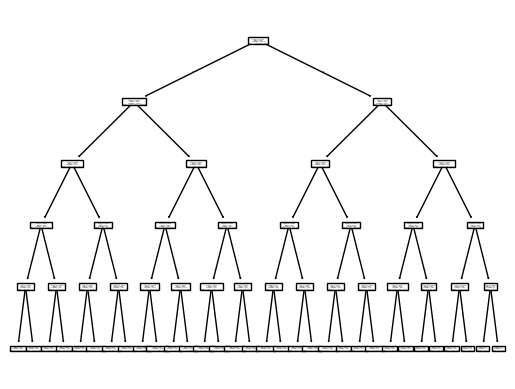

In [22]:
from sklearn import tree
# --- Your code here --- #
X, y = dataset.train["hog"], dataset.train["labels"]
clf = tree.DecisionTreeClassifier(max_depth=5)
clf = clf.fit(X, y)

tree.plot_tree(clf)

In [20]:
from sklearn import tree
from sklearn.model_selection import GridSearchCV

# --- Your code here --- #

# Define the parameter grid
param_grid = {
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10]
}


X, y = dataset.train["hog"], dataset.train["labels"]
dt = tree.DecisionTreeClassifier()
dt = dt.fit(X, y)

# Create Random Forest model
grid_search = GridSearchCV(estimator=dt, param_grid=param_grid, cv=5, n_jobs=-1)

# Fit the model
grid_search.fit(X, y)

# Best parameters found
print("Best parameters:", grid_search.best_params_)


# Evaluate the best model from GridSearchCV on the test set
best_dt = grid_search.best_estimator_
print("Test set accuracy:", best_dt.score(dataset.test["hog"],dataset.test["labels"]))

Best parameters: {'max_depth': 10, 'min_samples_split': 2}
Test set accuracy: 0.598


## 3. Random Forests

[Random Forest](http://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) classifiers use multiple decision trees trained on "weaker" datasets (less data and/or less features), averaging the results so as to reduce over-fitting.

* Use scikit-learn to **create a Random Forest classifier** on the CIFAR data. 
* Use cross-validation to find the best hyper-paramters for this method.

In [19]:
from sklearn import ensemble
from sklearn.model_selection import GridSearchCV

# --- Your code here --- #

# Define the parameter grid
param_grid = {
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10]
}


X, y = dataset.train["hog"], dataset.train["labels"]
rf = ensemble.RandomForestClassifier()
rf = rf.fit(X, y)


# Create Random Forest model
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1)

# Fit the model
grid_search.fit(X, y)

# Best parameters found
print("Best parameters:", grid_search.best_params_)


# Evaluate the best model from GridSearchCV on the test set
best_rf = grid_search.best_estimator_
print("Test set accuracy:", best_rf.score(dataset.test["hog"],dataset.test["labels"]))

Best parameters: {'max_depth': 20, 'min_samples_split': 2}
Test set accuracy: 0.7646666666666667
